Libraries

In [1]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Dense, Dropout,
                                     Flatten, BatchNormalization,
                                     GlobalAveragePooling2D)
from tensorflow.keras.callbacks import (EarlyStopping,
                                        ModelCheckpoint,
                                        ReduceLROnPlateau)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             f1_score, roc_auc_score)
from sklearn.utils.class_weight import compute_class_weight

print('Libraries imported!')
print(f'TensorFlow version: {tf.__version__}')

Libraries imported!
TensorFlow version: 2.21.0


Loading Data

In [2]:
path = r'C:\Users\nbush\OneDrive - University of Huddersfield\Desktop\FYP\preprocessed'

X_train = np.load(f'{path}\\X_train_images.npy')
X_val   = np.load(f'{path}\\X_val_images.npy')
X_test  = np.load(f'{path}\\X_test_images.npy')
y_train = np.load(f'{path}\\y_train_images.npy')
y_val   = np.load(f'{path}\\y_val_images.npy')
y_test  = np.load(f'{path}\\y_test_images.npy')

classes     = ['MildDemented', 'ModerateDemented',
               'NonDemented', 'VeryMildDemented']
num_classes = len(classes)

print('Data loaded!')
print(f'X_train : {X_train.shape}')
print(f'X_val   : {X_val.shape}')
print(f'X_test  : {X_test.shape}')

Data loaded!
X_train : (4480, 128, 128, 3)
X_val   : (960, 128, 128, 3)
X_test  : (960, 128, 128, 3)


One-Hot Encoding

In [3]:
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val,   num_classes)
y_test_cat  = to_categorical(y_test,  num_classes)

print('One-Hot Encoding done!')

One-Hot Encoding done!


Class Weights

In [4]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

print('Class Weights:')
for cls, weight in zip(classes, class_weights):
    print(f'  {cls}: {weight:.3f}')

Class Weights:
  MildDemented: 1.786
  ModerateDemented: 24.889
  NonDemented: 0.500
  VeryMildDemented: 0.714


VGG16 Model

In [5]:
# VGG16 base load karo
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

# Pehle sab freeze karo
base_model.trainable = False

# Sirf last 4 layers unfreeze karo
for layer in base_model.layers[-4:]:
    layer.trainable = True

print('Trainable layers:')
for layer in base_model.layers:
    print(f'  {layer.name}: {layer.trainable}')

# Top layers add karo
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(num_classes,
               activation='softmax')(x)

model = Model(inputs=base_model.input,
              outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'\nTotal layers     : {len(model.layers)}')
print(f'Trainable layers : '
      f'{len([l for l in model.layers if l.trainable])}')
print(f'Frozen layers    : '
      f'{len([l for l in model.layers if not l.trainable])}')
print('VGG16 Fine-tuned model ready!')

Trainable layers:
  input_layer: False
  block1_conv1: False
  block1_conv2: False
  block1_pool: False
  block2_conv1: False
  block2_conv2: False
  block2_pool: False
  block3_conv1: False
  block3_conv2: False
  block3_conv3: False
  block3_pool: False
  block4_conv1: False
  block4_conv2: False
  block4_conv3: False
  block4_pool: False
  block5_conv1: True
  block5_conv2: True
  block5_conv3: True
  block5_pool: True

Total layers     : 26
Trainable layers : 11
Frozen layers    : 15
VGG16 Fine-tuned model ready!


Callbacks

In [6]:
save_path = r'C:\Users\nbush\OneDrive - University of Huddersfield\Desktop\FYP\preprocessed'

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=f'{save_path}\\best_vgg16_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=0.000001,
        verbose=1
    )
]

print('Callbacks ready!')

Callbacks ready!


Training

In [7]:
datagen = ImageDataGenerator(
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    zoom_range=0.05
)

datagen.fit(X_train)

print('VGG16 Training started...')
print('Laptop band mat karna!')

history = model.fit(
    datagen.flow(X_train, y_train_cat,
                 batch_size=32),
    validation_data=(X_val, y_val_cat),
    epochs=30,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

print('Training complete!')

VGG16 Training started...
Laptop band mat karna!
Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2808 - loss: 1.4852
Epoch 1: val_accuracy improved from None to 0.21146, saving model to C:\Users\nbush\OneDrive - University of Huddersfield\Desktop\FYP\preprocessed\best_vgg16_model.keras

Epoch 1: finished saving model to C:\Users\nbush\OneDrive - University of Huddersfield\Desktop\FYP\preprocessed\best_vgg16_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 389s 3s/step - accuracy: 0.2940 - loss: 1.4512 - val_accuracy: 0.2115 - val_loss: 1.3894 - learning_rate: 1.0000e-05
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3375 - loss: 1.3040
Epoch 2: val_accuracy improved from 0.21146 to 0.40729, saving model to C:\Users\nbush\OneDrive - University of Huddersfield\Desktop\FYP\preprocessed\best_vgg16_model.keras

Epoch 2: finished saving model to C:\Users\nbush\OneDrive - University of Huddersfield\Desktop\FYP\preprocessed\best_vgg16_model.keras
140/140 ━━━━━━━━━━━━

Training Graphs

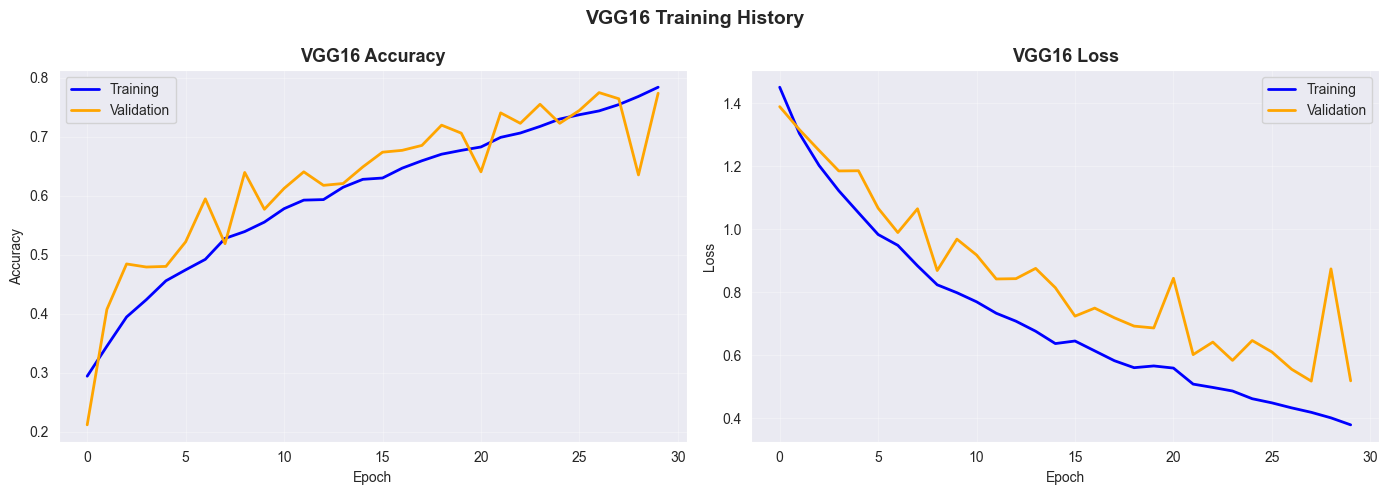

Graph saved!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],
             label='Training',
             color='blue', linewidth=2)
axes[0].plot(history.history['val_accuracy'],
             label='Validation',
             color='orange', linewidth=2)
axes[0].set_title('VGG16 Accuracy',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],
             label='Training',
             color='blue', linewidth=2)
axes[1].plot(history.history['val_loss'],
             label='Validation',
             color='orange', linewidth=2)
axes[1].set_title('VGG16 Loss',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('VGG16 Training History',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('vgg16_training_history.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Graph saved!')

Evaluate

In [9]:
test_loss, test_acc = model.evaluate(
    X_test, y_test_cat, verbose=0
)

y_pred_proba = model.predict(X_test)
y_pred       = np.argmax(y_pred_proba, axis=1)

f1  = f1_score(y_test, y_pred,
               average='weighted')
auc = roc_auc_score(y_test_cat, y_pred_proba,
                    multi_class='ovr',
                    average='weighted')

print('=' * 50)
print('     VGG16 — FINAL RESULTS')
print('=' * 50)
print(f'Accuracy : {test_acc*100:.2f}%')
print(f'F1-Score : {f1*100:.2f}%')
print(f'ROC-AUC  : {auc*100:.2f}%')
print('=' * 50)

30/30 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step
     VGG16 — FINAL RESULTS
Accuracy : 75.94%
F1-Score : 76.11%
ROC-AUC  : 90.83%


Classification Report

In [11]:
print('VGG16 Classification Report:')
print('=' * 55)
print(classification_report(
    y_test, y_pred,
    target_names=classes
))

VGG16 Classification Report:
                  precision    recall  f1-score   support

    MildDemented       0.67      0.93      0.78       135
ModerateDemented       1.00      1.00      1.00         9
     NonDemented       0.89      0.70      0.78       480
VeryMildDemented       0.67      0.77      0.72       336

        accuracy                           0.76       960
       macro avg       0.81      0.85      0.82       960
    weighted avg       0.78      0.76      0.76       960


Save Results

In [12]:
import pandas as pd

vgg16_results = pd.DataFrame({
    'Model'   : ['VGG16'],
    'Accuracy': [round(test_acc * 100, 2)],
    'F1-Score': [round(f1 * 100, 2)],
    'ROC-AUC' : [round(auc * 100, 2)]
})

vgg16_results.to_csv(
    f'{save_path}\\vgg16_results.csv',
    index=False
)

print('Results saved!')
print('=' * 50)
print('       VGG16 COMPLETE! ')
print('=' * 50)
print(vgg16_results.to_string(index=False))
print('=' * 50)

Results saved!
       VGG16 COMPLETE! 
Model  Accuracy  F1-Score  ROC-AUC
VGG16     75.94     76.11    90.83
